# Normalization Validation — PI3 & PI4
Lilly Ko

Validation notebook for the normalization pipeline in `normalize.py`.
PI1, PI2, and PI5 are implemented in `normalize.py`. This notebook covers the
validation (PI3) and consistency evaluation (PI4) so that the diagrams can be imaged. 

In [11]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
import pandas as pd
import librosa

sys.path.insert(0, str(Path('.').resolve()))
from normalize import compare_distributions, evaluate_consistency, NormalizationPipeline


RECORDINGS_DIR = Path('data/raw/recordings')
recording_paths = sorted(RECORDINGS_DIR.glob('*.wav'))
print(f'\nFound {len(recording_paths)} recording(s):')
for p in recording_paths:
    print(f'  {p.name}')


def load_wav(path):
    sr, audio = wavfile.read(str(path))
    audio = audio.astype(np.float32)
    if np.abs(audio).max() > 1.0:
        audio = audio / 32768.0
    if audio.ndim > 1:
        audio = audio.mean(axis=1)
    return audio, sr


pipeline = NormalizationPipeline()


Found 3 recording(s):
  mic_capture_ui_20260226_211554.wav
  mic_monitor_20260226_234918.wav
  mic_monitor_20260226_234943.wav


## PI3 — Validate Normalization

Check that the normalization is actually doing what it should. Extract MFCCs
before and after the pipeline and compare the distributions — after CMVN the
coefficients should be centered around zero with roughly unit variance.

Distribution Comparison — all MFCC frames and coefficients flattened:
         Before   After     Delta
mean   -20.4516  0.0000   20.4516
std    111.7901  1.0000 -110.7901
min   -566.3128 -3.1336  563.1792
max    186.3610  3.3173 -183.0438
p25    -28.3243 -0.7216   27.6027
p75     18.5131  0.7287  -17.7844
rms    113.6455  1.0000 -112.6455
range  752.6738  6.4509 -746.2230



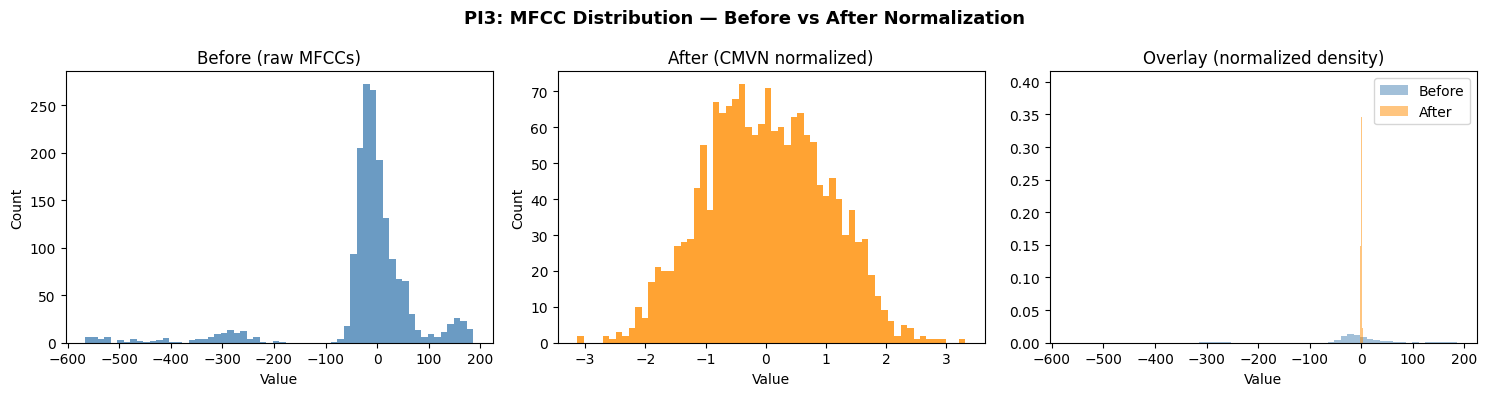

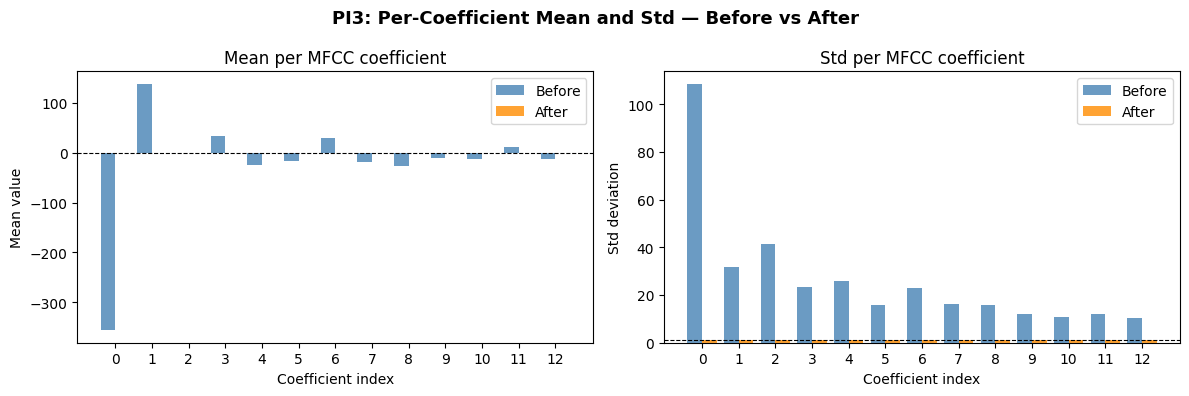

In [12]:
pipeline = NormalizationPipeline()

audio, sr = load_wav(recording_paths[0])

# Before: raw MFCCs, no normalization
mfcc_raw = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=13, n_fft=1024, hop_length=512).T

# After: full pipeline (RMS normalize → compress → CMVN)
mfcc_norm = pipeline.extract_and_normalize_features(audio, sr)

# Stats table
stats = compare_distributions(mfcc_raw, mfcc_norm)
df_stats = pd.DataFrame({
    'Before': stats['before'],
    'After': stats['after'],
    'Delta': stats['delta'],
})
print('Distribution Comparison — all MFCC frames and coefficients flattened:')
print(df_stats.to_string(float_format='{:.4f}'.format))
print()

# Histogram comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('PI3: MFCC Distribution — Before vs After Normalization', fontsize=13, fontweight='bold')

flat_raw = mfcc_raw.flatten()
flat_norm = mfcc_norm.flatten()

axes[0].hist(flat_raw, bins=60, color='steelblue', alpha=0.8)
axes[0].set_title('Before (raw MFCCs)')
axes[0].set_xlabel('Value')
axes[0].set_ylabel('Count')

axes[1].hist(flat_norm, bins=60, color='darkorange', alpha=0.8)
axes[1].set_title('After (CMVN normalized)')
axes[1].set_xlabel('Value')
axes[1].set_ylabel('Count')

axes[2].hist(flat_raw, bins=60, color='steelblue', alpha=0.5, label='Before', density=True)
axes[2].hist(flat_norm, bins=60, color='darkorange', alpha=0.5, label='After', density=True)
axes[2].set_title('Overlay (normalized density)')
axes[2].set_xlabel('Value')
axes[2].legend()

plt.tight_layout()
plt.show()

# Per-coefficient mean and std
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('PI3: Per-Coefficient Mean and Std — Before vs After', fontsize=13, fontweight='bold')

coeff_idx = np.arange(13)

axes[0].bar(coeff_idx - 0.2, mfcc_raw.mean(axis=0), width=0.4, color='steelblue', alpha=0.8, label='Before')
axes[0].bar(coeff_idx + 0.2, mfcc_norm.mean(axis=0), width=0.4, color='darkorange', alpha=0.8, label='After')
axes[0].set_title('Mean per MFCC coefficient')
axes[0].set_xlabel('Coefficient index')
axes[0].set_ylabel('Mean value')
axes[0].set_xticks(coeff_idx)
axes[0].axhline(0, color='k', lw=0.8, ls='--')
axes[0].legend()

axes[1].bar(coeff_idx - 0.2, mfcc_raw.std(axis=0), width=0.4, color='steelblue', alpha=0.8, label='Before')
axes[1].bar(coeff_idx + 0.2, mfcc_norm.std(axis=0), width=0.4, color='darkorange', alpha=0.8, label='After')
axes[1].set_title('Std per MFCC coefficient')
axes[1].set_xlabel('Coefficient index')
axes[1].set_ylabel('Std deviation')
axes[1].set_xticks(coeff_idx)
axes[1].axhline(1, color='k', lw=0.8, ls='--')
axes[1].legend()

plt.tight_layout()
plt.show()

## PI4 — Model Input Consistency

Check how consistent the feature vectors are across different recordings.
Lower variance across recordings means the SVM will see more uniform inputs,
which generally makes training more stable.

PI4: Cross-Recording Variance (lower = more consistent model inputs)

  mean_cross_variance: 208.6187 → 0.0000  (100.0% reduction)
  max_cross_variance: 1557.9135 → 0.0000  (100.0% reduction)


/Users/lilly/voice-detection/voice-detection/normalize.py:119: RuntimeWarning: invalid value encountered in divide
  gain = np.where(abs_a > 1e-8, compressed_abs / abs_a, 1.0)


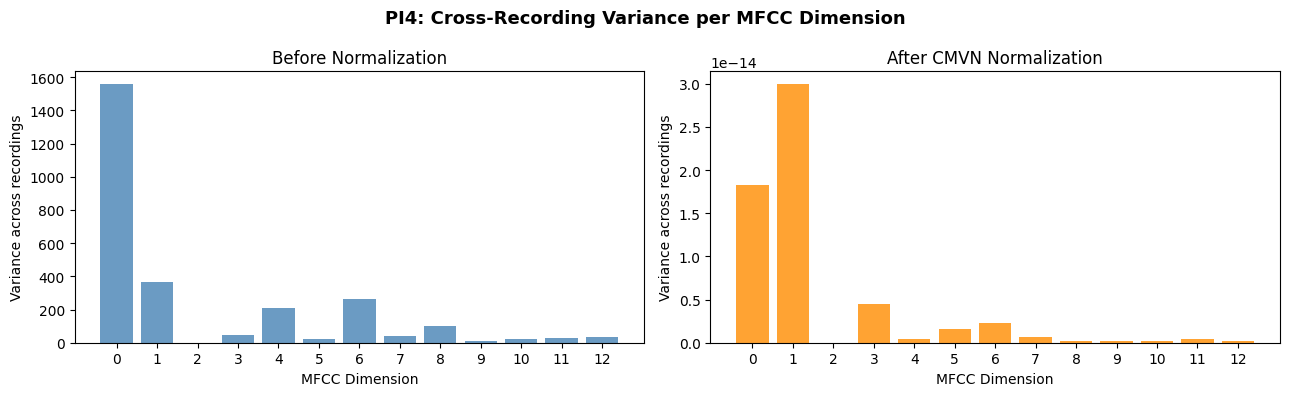

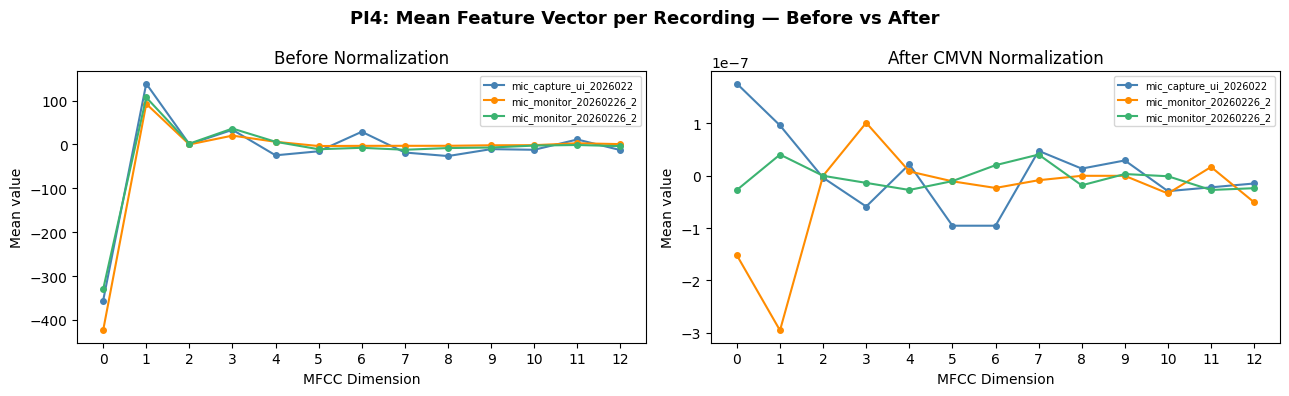

Lines closer together = more consistent model inputs = more stable SVM training.


In [13]:
features_raw = []
features_norm = []

for path in recording_paths:
    audio, sr = load_wav(path)
    mfcc_raw = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=13, n_fft=1024, hop_length=512).T
    mfcc_norm = pipeline.extract_and_normalize_features(audio, sr)
    features_raw.append(mfcc_raw)
    features_norm.append(mfcc_norm)

cons_raw = evaluate_consistency(features_raw)
cons_norm = evaluate_consistency(features_norm)

print('PI4: Cross-Recording Variance (lower = more consistent model inputs)')
print()
for m in ['mean_cross_variance', 'max_cross_variance']:
    b = cons_raw[m]
    a = cons_norm[m]
    reduction = (b - a) / b * 100 if b > 0 else 0.0
    print(f'  {m}: {b:.4f} → {a:.4f}  ({reduction:.1f}% reduction)')

# Per-dimension variance bar charts
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('PI4: Cross-Recording Variance per MFCC Dimension', fontsize=13, fontweight='bold')

coeff_idx = np.arange(13)

axes[0].bar(coeff_idx, cons_raw['per_dim_variance'], color='steelblue', alpha=0.8)
axes[0].set_title('Before Normalization')
axes[0].set_xlabel('MFCC Dimension')
axes[0].set_ylabel('Variance across recordings')
axes[0].set_xticks(coeff_idx)

axes[1].bar(coeff_idx, cons_norm['per_dim_variance'], color='darkorange', alpha=0.8)
axes[1].set_title('After CMVN Normalization')
axes[1].set_xlabel('MFCC Dimension')
axes[1].set_ylabel('Variance across recordings')
axes[1].set_xticks(coeff_idx)

plt.tight_layout()
plt.show()

# Mean feature vector per recording — shows how tightly they cluster after normalization
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('PI4: Mean Feature Vector per Recording — Before vs After', fontsize=13, fontweight='bold')

colors = ['steelblue', 'darkorange', 'mediumseagreen', 'orchid']
for i, (raw, norm, path) in enumerate(zip(features_raw, features_norm, recording_paths)):
    c = colors[i % len(colors)]
    label = path.name[:22]
    axes[0].plot(coeff_idx, raw.mean(axis=0), color=c, marker='o', ms=4, label=label)
    axes[1].plot(coeff_idx, norm.mean(axis=0), color=c, marker='o', ms=4, label=label)

for ax, title in zip(axes, ['Before Normalization', 'After CMVN Normalization']):
    ax.set_title(title)
    ax.set_xlabel('MFCC Dimension')
    ax.set_ylabel('Mean value')
    ax.set_xticks(coeff_idx)
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()
print('Lines closer together = more consistent model inputs = more stable SVM training.')